<a href="https://colab.research.google.com/github/peremartra/Rearchitecting-LLMs/blob/main/CH08/CH08_NB03_Remove_Attention_15L.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="width:100%; border:none; background:none;">
  <tr style="border:none;">
    <td style="border:none; vertical-align:middle; text-align:left; width: 120px;">
      <a href="https://hubs.la/Q040tvsK0"><img src="https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/Images/cover.png" width="100px" style="border-radius: 4px;"></a>
    </td>
    <td style="border:none; vertical-align:middle; text-align:left;">
      <p style="margin: 0; font-size: 14px;">
        Supplementary code for the <a href="https://hubs.la/Q040tvsK0">Rearchitecting LLMs</a> book by <a href="https://github.com/peremartra">Pere Martra</a>.<br>
        <br>
        Code repository: <a href="https://github.com/peremartra/Rearchitecting-LLMs">https://github.com/peremartra/Rearchitecting-LLMs</a>
      </p>
    </td>
  </tr>
</table>

# Chapter 8 — Attention Optimization
## NB03: Removing Redundant Attention Layers (15 vs 6)

[![LinkedIn](https://img.shields.io/badge/LinkedIn-blue?logo=linkedin)](https://www.linkedin.com/in/pere-martra/) [![GitHub](https://img.shields.io/badge/GitHub-black?logo=github)](https://github.com/peremartra) [![X](https://img.shields.io/badge/X-000000?logo=x)](https://x.com/peraborges) [![Hugging Face](https://img.shields.io/badge/%F0%9F%A4%97%20Hugging%20Face-yellow)](https://huggingface.co/oopere)

**Supplementary code for the [Rearchitecting LLMs](https://www.manning.com/books/rearchitecting-large-language-models) book by [Pere Martra](https://www.yourwebsite.com).**

**Code repository:** [https://github.com/peremartra/Rearchitecting-LLMs](https://github.com/peremartra/Rearchitecting-LLMs)

- **Author:** Pere Martra
- **Model:** `meta-llama/Llama-3.2-3B`
- **Colab Environment:** T4 GPU
- **Keys:**
  - Physical Attention Pruning
  - Comparative Evaluation Across Pruning Levels
- **References:**
  - [Manning Book: Rearchitecting LLMs](https://www.manning.com/books/rearchitecting-large-language-models)
  - [Not All Attention is Needed](https://arxiv.org/abs/2406.15786)

This notebook implements physical attention layer removal based on the paper
[What Matters in Transformers? Not All Attention is Needed](https://arxiv.org/abs/2406.15786) (He et al., 2024).

Unlike the KV cache techniques in NB01 and NB02, here we permanently delete the least important
attention modules from the model architecture. The notebook runs two pruning experiments over the
same model and data pipeline: removing 15 layers and removing 6 layers. Both variants are evaluated
with the same prompts and the same benchmark suite to compare quality, memory, and inference behavior.

**Model:** `meta-llama/Llama-3.2-3B`  
**Environment:** Google Colab T4 (free tier)  

## Setting up notebook


In [38]:
!pip install -q \
      "torch" \
      "transformers==4.55.4" \
      "accelerate==1.10.1" \
      "lm_eval==0.4.9.1" \
      "sentencepiece==0.2.1" \
      "langdetect" \
      "datasets" \
      "codecarbon" \
      "optipfair==0.2.1"

In [39]:
# Pull the shared utility module from the chapter repository
!wget -q https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/utils.py

In [40]:
import os
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset, Dataset

# Shared utilities: get_output is used in Section 6 to verify
# that the pruned model generates coherent text after reloading
from utils import get_output, model_evaluation, measure_memory_allocation

In [41]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
print("✓ Random seed set to 42")

✓ Random seed set to 42


In [42]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Experiment configuration
All global parameters are defined here, including the list of pruning experiments.
This notebook will run the same generation prompts and benchmark tasks for each value
in `EXPERIMENT_LAYERS_TO_DROP` so results remain directly comparable.

In [43]:
MODEL_NAME = "meta-llama/Llama-3.2-3B"
EXPERIMENT_LAYERS_TO_DROP = [15, 6]
CALIBRATION_SAMPLES = 400  # Total samples across all Cosmopedia subsets
RUN_FULL_BENCHMARKS = True
BENCHMARK_LIMIT = None
BENCHMARK_BATCH_SIZE = 4

# Shared prompts: executed for baseline and for every pruned variant.
BASELINE_PROMPT = "Paris is the capital of"
PROMPT = (
    "Explain in detail the history of artificial intelligence, "
    "covering all major milestones from the 1950s to the present day."
)
MAX_NEW_TOKENS = 500

# Benchmarks: run on baseline and all pruning variants.
BENCHMARK_TASKS = [
    "arc_easy",
    "winogrande",
    "hellaswag",
    "lambada_openai",
    "piqa",
]

## Load the model

We load `meta-llama/Llama-3.2-3B` in fp16 precision. On a T4 GPU, bfloat16 is not supported.
If you are running on an L4 or any Ampere-class GPU or newer, replace `torch.float16` with
`torch.bfloat16` in the configuration cell for better numerical stability during calibration
and during the two pruning experiments (15 and 6 layers).

In [44]:
# fp16: correct choice for T4 GPUs
# Switch to torch.bfloat16 if running on L4 or any Ampere-class GPU or newer
TORCH_DTYPE = torch.float16

In [45]:
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=TORCH_DTYPE,
    device_map=device
)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Before making any changes, it is worth pausing to look at the model architecture.
Each `LlamaDecoderLayer` contains two top-level submodules that concern us:
`input_layernorm` and `self_attn`. When we remove an attention module in Section 5,
we will delete both — the LayerNorm exists solely to normalize the input before

In [46]:
# Inspect the full model structure before any modifications
print(model)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 3072)
    (layers): ModuleList(
      (0-27): 28 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=3072, out_features=3072, bias=False)
          (k_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (v_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (o_proj): Linear(in_features=3072, out_features=3072, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=3072, out_features=8192, bias=False)
          (up_proj): Linear(in_features=3072, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=3072, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((3072,), eps=1e-05)
    (rotary_emb

Finally, a quick generation check confirms the baseline model is working correctly.
This exact prompt will also be used for both pruned variants (drop-15 and drop-6).

In [47]:
baseline_output = get_output(model, tokenizer, BASELINE_PROMPT)
print(f"Baseline output:\n{baseline_output}")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Baseline output:
 France and the largest city in the country. It is located in the north-central part of the country, on the banks of the Seine River. The city is known for its rich history, culture, and architecture. It is also a major center for business, finance, and tourism.
Paris is a city of many faces. It is a city of art and culture, a city of history and tradition, and a city of modernity and innovation. It is a city that is constantly evolving,


In [48]:
# Run standard benchmarks on the baseline model.
if RUN_FULL_BENCHMARKS:
    print("Running benchmarks on baseline model...")
    base_benchmarks = model_evaluation(
        model, tokenizer, BENCHMARK_TASKS,
        device=device, limit=BENCHMARK_LIMIT, batch_size=BENCHMARK_BATCH_SIZE
    )
    print("\nBaseline benchmark results:")
    for task, metrics in base_benchmarks.items():
        print(f"  {task}: {metrics}")
else:
    base_benchmarks = {}
    print("Skipping benchmarks (RUN_FULL_BENCHMARKS=False)")

Running benchmarks on baseline model...
Starting lm-eval on model 'meta-llama/Llama-3.2-3B' for tasks: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']



Tasks grouped by few-shot: {0: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']} (full dataset)
Task-level few-shot config: {'arc_easy': 0, 'winogrande': 0, 'hellaswag': 0, 'lambada_openai': 0, 'piqa': 0}

Evaluating 5 task(s) with 0-shot learning...


README.md: 0.00B [00:00, ?B/s]

ARC-Easy/train-00000-of-00001.parquet:   0%|          | 0.00/331k [00:00<?, ?B/s]

ARC-Easy/test-00000-of-00001.parquet:   0%|          | 0.00/346k [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/3084 [00:00<?, ? examples/s]

Running loglikelihood requests: 100%|██████████| 61032/61032 [1:02:05<00:00, 16.38it/s]


bootstrapping for stddev: perplexity


100%|██████████| 100/100 [00:50<00:00,  1.96it/s]



Baseline benchmark results:
  arc_easy: {'accuracy': '0.7449', 'acc_norm': '0.7168'}
  hellaswag: {'accuracy': '0.5526', 'acc_norm': '0.7360'}
  lambada_openai: {'perplexity': '3.94', 'accuracy': '0.7050'}
  piqa: {'accuracy': '0.7671', 'acc_norm': '0.7758'}
  winogrande: {'accuracy': '0.6969'}


In [49]:
base_benchmarks

{'arc_easy': {'accuracy': '0.7449', 'acc_norm': '0.7168'},
 'hellaswag': {'accuracy': '0.5526', 'acc_norm': '0.7360'},
 'lambada_openai': {'perplexity': '3.94', 'accuracy': '0.7050'},
 'piqa': {'accuracy': '0.7671', 'acc_norm': '0.7758'},
 'winogrande': {'accuracy': '0.6969'}}

## Measuring attention layer contribution

Before we can decide which attention modules to remove, we need to measure how much
each one actually contributes to the model's computation. The metric we use is cosine
similarity between the input and the output of each attention sublayer — including
the residual connection. A module whose output is nearly identical to its input is
doing very little work and is a strong candidate for removal.

### Calibration data

Importance scores are not absolute properties of a layer — they depend on the text
the model is asked to process. A layer that appears redundant on conversational text
might be active and necessary on dense academic prose. For this reason we use
Cosmopedia, a dataset that mixes several content types, as our calibration source.
The weighted sampling below ensures that the scores we compute reflect the model's
behavior across a realistic distribution of tasks, not just one narrow domain.

In [50]:
from datasets import load_dataset, Dataset
from torch.utils.data import DataLoader

BATCH_SIZE = 4
MAX_LENGTH = 2048

dataset_name = "HuggingFaceTB/cosmopedia"

# Subsets weighted to cover the same range of tasks as our benchmarks:
# stories and web samples activate contextual reasoning (hellaswag, winogrande),
# wikihow activates procedural understanding (piqa),
# openstax and stanford activate academic reasoning (arc_easy)
subsets = [
    ("stories",        0.300),
    ("web_samples_v2", 0.200),
    ("web_samples_v1", 0.150),
    ("wikihow",        0.150),
    ("openstax",       0.125),
    ("stanford",       0.075),
]

assert abs(sum(w for _, w in subsets) - 1.0) < 1e-6, "Weights must sum to 1.0"

all_samples = []
for subset, weight in subsets:
    n_samples = int(CALIBRATION_SAMPLES * weight)
    print(f"  Loading {subset} ({n_samples:,} samples, weight={weight:.3f})...")
    subset_data = load_dataset(dataset_name, subset, split="train", streaming=True)
    subset_samples = list(subset_data.take(n_samples))
    all_samples.extend(subset_samples)
    print(f"    Collected {len(subset_samples):,} samples")

calibration_dataset = Dataset.from_dict({"text": [s["text"] for s in all_samples]})
print(f"\nTotal calibration samples: {len(calibration_dataset):,}")

  Loading stories (120 samples, weight=0.300)...


Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/43 [00:00<?, ?it/s]

    Collected 120 samples
  Loading web_samples_v2 (80 samples, weight=0.200)...


Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

...

    Collected 60 samples
  Loading openstax (50 samples, weight=0.125)...


Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

    Collected 50 samples
  Loading stanford (30 samples, weight=0.075)...


Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

    Collected 30 samples

Total calibration samples: 400


In [51]:
def prepare_dataset(dataset, tokenizer, max_length=MAX_LENGTH, batch_size=BATCH_SIZE):
    def tokenize_function(examples):
        return tokenizer(
            examples["text"],
            truncation=True,
            padding="max_length",
            max_length=max_length,
            return_tensors=None,
        )
    tokenized = dataset.map(
        tokenize_function,
        batched=True,
        remove_columns=dataset.column_names
    )
    def collate_fn(examples):
        input_ids = torch.tensor([e["input_ids"] for e in examples], dtype=torch.long)
        attention_mask = torch.tensor([e["attention_mask"] for e in examples], dtype=torch.long)
        return {"input_ids": input_ids, "attention_mask": attention_mask}

    return DataLoader(tokenized, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

In [52]:
calibration_dataloader = prepare_dataset(calibration_dataset, tokenizer)
print(f"Calibration dataloader ready: {len(calibration_dataloader)} batches of {BATCH_SIZE}")

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Calibration dataloader ready: 100 batches of 4


### 3.2 — Registering hooks and computing importance scores

To measure each attention sublayer's contribution we use PyTorch forward hooks —
the same mechanism introduced in Chapter 4 to measure Transformer block importance.
The logic is identical: register a hook to capture the input and output of a module,
run a forward pass, and compute the cosine distance between the two tensors.

The key difference lies in **where we anchor the hooks**.

In Chapter 4 we hooked into each `DecoderLayer` directly, capturing the input and
output of the entire Transformer block — attention sublayer and MLP sublayer together.
That was the right granularity for depth pruning, where we removed complete blocks.

Here we need finer resolution. We want to measure the contribution of the attention
sublayer in isolation, so we anchor the hooks one level deeper:

- A **pre-hook on `layer.input_layernorm`** captures X_A: the hidden state arriving
  at the attention sublayer before any transformation.
- A **pre-hook on `layer.post_attention_layernorm`** captures Y_A: the hidden state
  after the attention computation and its residual connection have been applied,
  i.e. X_A + Attention(LayerNorm(X_A)).

Measuring between these two points — and not between the internal projections of
the attention module — is what the paper identifies as critical. Including the residual
connection in the measurement prevents us from underestimating the contribution of
layers that rely on it to preserve information flow.

In [53]:
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm

def setup_attention_hooks(model):
    """
    Register pre-hooks to capture the input and output of each attention sublayer.

    We hook into input_layernorm (to get X_A) and post_attention_layernorm
    (to get Y_A = X_A + Attention(LayerNorm(X_A))). This mirrors the importance
    metric defined in the paper: S = 1 - CosineSim(X_A, Y_A).
    """
    num_layers = len(model.model.layers)
    layer_inputs  = {}  # X_A per layer
    layer_outputs = {}  # Y_A per layer
    hooks = []

    def make_input_hook(layer_idx):
        def hook(module, args):
            # args[0] is the hidden state entering input_layernorm
            layer_inputs[layer_idx] = args[0].detach()
        return hook

    def make_output_hook(layer_idx):
        def hook(module, args):
            # args[0] is the hidden state entering post_attention_layernorm,
            # which is X_A + Attention(LayerNorm(X_A)) — residual already applied
            layer_outputs[layer_idx] = args[0].detach()
        return hook

    for i, layer in enumerate(model.model.layers):
        hooks.append(layer.input_layernorm.register_forward_pre_hook(make_input_hook(i)))
        hooks.append(layer.post_attention_layernorm.register_forward_pre_hook(make_output_hook(i)))

    return hooks, layer_inputs, layer_outputs, num_layers

In [54]:
import torch.nn.functional as F

def calculate_cosine_importance(input_tensor, output_tensor, attention_mask, layer_idx, is_first_batch=False):
    """
    Computes the importance score of an attention sublayer for a single batch,
    properly masking out padding tokens to prevent artificial similarity inflation.
    """
    if input_tensor.numel() == 0 or output_tensor.numel() == 0:
        return 0.0

    # Calculate cosine similarity along the hidden state dimension (dim=-1)
    # Tensors shape: [batch_size, seq_len, hidden_size] -> similarities shape: [batch_size, seq_len]
    similarities = F.cosine_similarity(input_tensor, output_tensor, dim=-1)

    # Ensure the attention mask matches the dimensions and device of the similarities tensor
    attention_mask = attention_mask.to(similarities.device)

    # Zero out similarity scores belonging to padding tokens (where mask is 0)
    valid_similarities = similarities * attention_mask

    # Count only the authentic text tokens present in the current batch
    num_valid_tokens = attention_mask.sum()

    if num_valid_tokens == 0:
        if is_first_batch:
            print(f"Warning: layer {layer_idx} contained only padding tokens in this batch.")
        return 0.0

    # Compute the average similarity strictly across non-padding tokens
    mean_similarity = valid_similarities.sum() / num_valid_tokens

    # Guard against non-finite metrics (NaN/Inf) that corrupt the aggregate results
    if not torch.isfinite(mean_similarity):
         if is_first_batch:
            print(f"Warning: layer {layer_idx} generated non-finite similarity values.")
         return 0.0

    # Importance metric calculation based on Equation 1: S = 1 - CosineSim(X, Y)
    return 1.0 - mean_similarity.item()

In [55]:
def calculate_attention_importance(model, dataloader, device):
    """
    Compute average importance scores for all attention sublayers
    over the full calibration dataset.

    For each batch we run a single forward pass, let the hooks capture
    X_A and Y_A for every layer, compute the per-layer importance score,
    and accumulate. Final scores are the mean across all batches.
    """
    hooks, layer_inputs, layer_outputs, num_layers = setup_attention_hooks(model)
    accumulated_scores = {i: [] for i in range(num_layers)}

    model.eval()
    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(dataloader, desc="Scoring attention layers")):
            inputs = {k: v.to(device) for k, v in batch.items()}
            model(**inputs)

            for layer_idx in range(num_layers):
                if layer_idx not in layer_inputs or layer_idx not in layer_outputs:
                    raise RuntimeError(f"Hook failed for layer {layer_idx}.")

                # Pass the batch attention mask to correctly isolate active text tokens
                score = calculate_cosine_importance(
                    layer_inputs[layer_idx],
                    layer_outputs[layer_idx],
                    batch["attention_mask"],
                    layer_idx,
                    is_first_batch=(batch_idx == 0)
                )
                accumulated_scores[layer_idx].append(score)

            # Release references so GPU memory is not held between batches
            layer_inputs.clear()
            layer_outputs.clear()

    # Remove hooks before returning to avoid interference with later calls
    for hook in hooks:
        hook.remove()

    # Average scores across all batches — layers with consistently low scores
    # are the strongest candidates for removal
    final_scores = {}
    for layer_idx, scores in accumulated_scores.items():
        valid = [s for s in scores if np.isfinite(s)]
        if not valid:
            raise RuntimeError(f"No valid scores captured for layer {layer_idx}.")
        final_scores[layer_idx] = np.mean(valid)

    return final_scores

In [56]:
attention_importance = calculate_attention_importance(model, calibration_dataloader, device)

# Print scores sorted by importance (ascending) so the pruning candidates
# are immediately visible at the top of the output
print(f"\nAttention layer importance scores (ascending — lowest = most redundant):")
print(f"{'Layer':>6}  {'Score':>10}")
print("-" * 22)
for layer_idx, score in sorted(attention_importance.items(), key=lambda x: x[1]):
    print(f"{layer_idx:>6}  {score:>10.6f}")

Scoring attention layers: 100%|██████████| 100/100 [06:48<00:00,  4.08s/it]


Attention layer importance scores (ascending — lowest = most redundant):
 Layer       Score
----------------------
    21    0.009053
    22    0.010405
    23    0.012417
    20    0.012783
    18    0.014297
    24    0.014580
    25    0.015039
    19    0.019702
    16    0.020107
    17    0.023384
    26    0.029893
    15    0.036753
    14    0.051890
    13    0.062476
    10    0.063799
    27    0.064468
     8    0.065161
     6    0.066108
     5    0.067041
    12    0.069980
     4    0.072007
     9    0.073247
    11    0.075723
     7    0.088350
     3    0.090088
     2    0.099155
     1    0.139336
     0    0.287197


## Visualizing layer importance

With the importance scores computed, we can now look at the distribution across
the model. Plotting scores by layer index — rather than by rank — reveals the
spatial pattern of redundancy: which parts of the network are active and which
are passive. This is more informative than a ranked list because it shows whether
redundant layers cluster in a specific region of the model or are spread throughout.

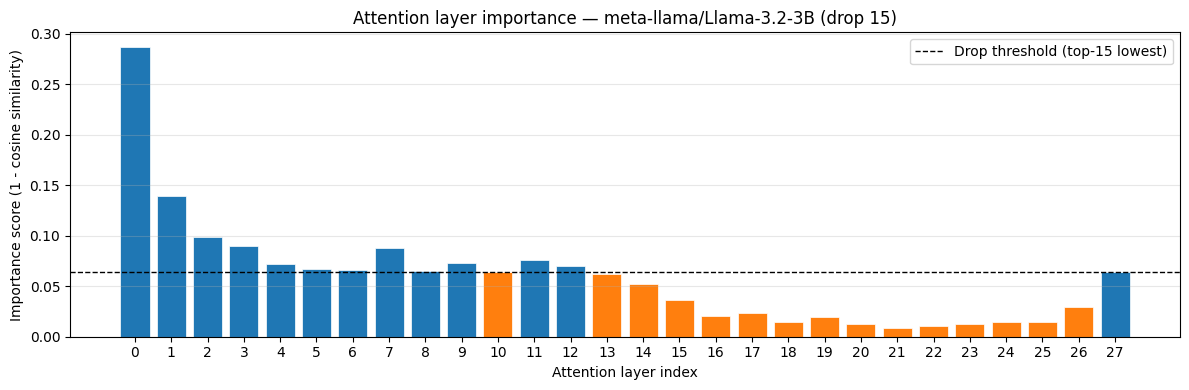

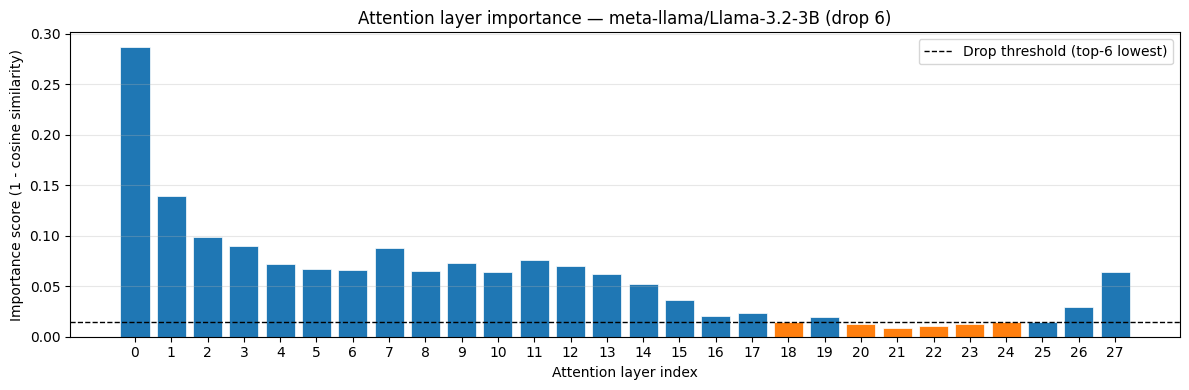

In [57]:
import matplotlib.pyplot as plt

def plot_attention_importance(scores, model_name, num_layers_to_drop):
    """
    Bar chart of attention sublayer importance scores ordered by layer index.
    Orange bars mark the pruning candidates; blue bars mark the layers kept.
    """
    layers = sorted(scores.keys())
    values = [scores[l] for l in layers]

    # Identify the score threshold that separates kept from dropped layers
    sorted_scores = sorted(values)
    drop_threshold = sorted_scores[num_layers_to_drop - 1]

    # Orange for pruning candidates, blue for retained layers
    colors = [
        "#ff7f0e" if v <= drop_threshold else "#1f77b4"
        for v in values
    ]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(layers, values, color=colors, edgecolor="white", linewidth=0.5)

    # Reference line at the drop threshold
    ax.axhline(
        y=drop_threshold,
        linestyle="--",
        linewidth=1.0,
        color="black",
        label=f"Drop threshold (top-{num_layers_to_drop} lowest)"
    )

    ax.set_xlabel("Attention layer index")
    ax.set_ylabel("Importance score (1 - cosine similarity)")
    ax.set_title(f"Attention layer importance — {model_name} (drop {num_layers_to_drop})")
    ax.set_xticks(layers)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

for n in EXPERIMENT_LAYERS_TO_DROP:
    plot_attention_importance(attention_importance, MODEL_NAME, n)

The charts use the same importance scores, but apply different thresholds for each experiment.
The 15-layer setup is intentionally aggressive and removes most low-activity layers.
The 6-layer setup is more conservative and keeps a larger fraction of mid-importance layers.

Because both experiments are derived from the same calibrated ranking, the comparison is fair:
only the pruning intensity changes, while prompts, benchmarks, and evaluation pipeline remain fixed.

In [58]:
import inspect; print(inspect.signature(model.model.layers[0].forward))

(hidden_states: torch.Tensor, attention_mask: Optional[torch.Tensor] = None, position_ids: Optional[torch.LongTensor] = None, past_key_value: Optional[transformers.cache_utils.Cache] = None, use_cache: Optional[bool] = False, cache_position: Optional[torch.LongTensor] = None, position_embeddings: Optional[tuple[torch.Tensor, torch.Tensor]] = None, **kwargs: Unpack[transformers.utils.generic.TransformersKwargs]) -> tuple[torch.Tensor]


## Physical deletion for multiple pruning levels

Selecting layers is straightforward: sort attention importance in ascending order and
take the first N indices. We repeat this for each experiment (N=15 and N=6), then
run the same save/reload/prompt/benchmark pipeline for each resulting model.

In [59]:
def select_layers_to_drop(importance_scores, num_layers_to_drop):
    """
    Return the indices of the least important attention layers.
    Sorting by score ascending puts the most redundant layers first.
    """
    sorted_layers = sorted(importance_scores.items(), key=lambda x: x[1])
    return [idx for idx, _ in sorted_layers[:num_layers_to_drop]]

layers_to_drop_by_experiment = {
    n: sorted(select_layers_to_drop(attention_importance, n))
    for n in EXPERIMENT_LAYERS_TO_DROP
}

for n in EXPERIMENT_LAYERS_TO_DROP:
    print(f"Layers selected for removal (drop {n}): {layers_to_drop_by_experiment[n]}")

Layers selected for removal (drop 15): [10, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]
Layers selected for removal (drop 6): [18, 20, 21, 22, 23, 24]


For each experiment we create a fresh copy of the base model, remove the selected attention
submodules (`self_attn` + `input_layernorm`), patch the affected layer forward pass, save
the model, reload it, and evaluate it.

Using a fresh model per experiment is essential: it guarantees that drop-15 and drop-6 are
independent runs, both starting from the same unmodified checkpoint.

In [60]:
from typing import Optional, Tuple
import gc
import json
import shutil

def drop_attention_layer(model, layer_idx):
    """
    Physically remove the attention submodules from a DecoderLayer and
    patch its forward() to route hidden states directly to the MLP block.
    """
    layer = model.model.layers[layer_idx]

    if hasattr(layer, "self_attn"):
        delattr(layer, "self_attn")
    if hasattr(layer, "input_layernorm"):
        delattr(layer, "input_layernorm")

    def forward_no_attn(
        self,
        hidden_states: torch.Tensor,
        attention_mask: Optional[torch.Tensor] = None,
        position_ids: Optional[torch.LongTensor] = None,
        past_key_value=None,
        use_cache: Optional[bool] = False,
        cache_position: Optional[torch.LongTensor] = None,
        position_embeddings: Optional[Tuple[torch.Tensor, torch.Tensor]] = None,
        **kwargs,
    ):
        if isinstance(hidden_states, tuple):
            hidden_states = hidden_states[0]
        residual = hidden_states
        hidden_states = self.post_attention_layernorm(hidden_states)
        hidden_states = self.mlp(hidden_states)
        hidden_states = residual + hidden_states
        return hidden_states

    PrunedLayer = type(
        "PrunedDecoderLayer",
        (type(layer),),
        {"forward": forward_no_attn}
    )
    layer.__class__ = PrunedLayer

def write_modeling_pruned_file(file_path="modeling_pruned_llama.py"):
    """Write the custom modeling class used when reloading pruned models."""
    modeling_code = '''
from typing import Optional, Tuple
import torch
from transformers import LlamaForCausalLM


class PrunedLlamaForCausalLM(LlamaForCausalLM):
    def __init__(self, config):
        super().__init__(config)
        dropped = getattr(config, "dropped_attn_layers", [])
        for idx in dropped:
            self._patch_layer(idx)

    def _patch_layer(self, layer_idx):
        layer = self.model.layers[layer_idx]

        if hasattr(layer, "self_attn"):
            delattr(layer, "self_attn")
        if hasattr(layer, "input_layernorm"):
            delattr(layer, "input_layernorm")

        def forward_no_attn(
            self,
            hidden_states: torch.Tensor,
            attention_mask: Optional[torch.Tensor] = None,
            position_ids: Optional[torch.LongTensor] = None,
            past_key_value=None,
            use_cache: Optional[bool] = False,
            cache_position: Optional[torch.LongTensor] = None,
            position_embeddings: Optional[Tuple[torch.Tensor, torch.Tensor]] = None,
            **kwargs,
        ):
            if isinstance(hidden_states, tuple):
                hidden_states = hidden_states[0]
            residual = hidden_states
            hidden_states = self.post_attention_layernorm(hidden_states)
            hidden_states = self.mlp(hidden_states)
            hidden_states = residual + hidden_states
            return hidden_states

        PrunedLayer = type(
            "PrunedDecoderLayer",
            (type(layer),),
            {"forward": forward_no_attn}
        )
        layer.__class__ = PrunedLayer
'''

    with open(file_path, "w") as f:
        f.write(modeling_code)

    return file_path

def compute_perplexity(model, tokenizer, prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        loss = model(**inputs, labels=inputs["input_ids"]).loss
    return torch.exp(loss).item()

def run_pruning_experiment(num_layers_to_drop):
    """Run one complete pruning experiment and return all relevant outputs."""
    print(f"\n===== Running experiment: drop {num_layers_to_drop} attention layers =====")

    exp_model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        torch_dtype=TORCH_DTYPE,
        device_map=device
    )

    layers_to_drop = layers_to_drop_by_experiment[num_layers_to_drop]
    for idx in layers_to_drop:
        drop_attention_layer(exp_model, idx)

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    exp_model.config.dropped_attn_layers = sorted(layers_to_drop)

    model_short_name = MODEL_NAME.split("/")[-1].lower()
    output_dir = f"./{model_short_name}-attn-drop-{num_layers_to_drop}"

    in_memory_output = get_output(exp_model, tokenizer, BASELINE_PROMPT)

    exp_model.config.auto_map = {
        "AutoModelForCausalLM": "modeling_pruned_llama.PrunedLlamaForCausalLM"
    }
    exp_model.save_pretrained(output_dir)
    tokenizer.save_pretrained(output_dir)
    shutil.copy("modeling_pruned_llama.py", output_dir)

    config_path = f"{output_dir}/config.json"
    with open(config_path, "r") as f:
        saved_config = json.load(f)

    reloaded_model = AutoModelForCausalLM.from_pretrained(
        output_dir,
        torch_dtype=TORCH_DTYPE,
        device_map=device,
        trust_remote_code=True,
    )

    reloaded_output = get_output(reloaded_model, tokenizer, BASELINE_PROMPT)
    memory_results = measure_memory_allocation(
        reloaded_model, tokenizer, PROMPT, max_new_tokens=MAX_NEW_TOKENS
    )
    ppl_reloaded = compute_perplexity(reloaded_model, tokenizer, PROMPT)

    if RUN_FULL_BENCHMARKS:
        benchmark_results = model_evaluation(
            reloaded_model, tokenizer, BENCHMARK_TASKS,
            device=device, limit=BENCHMARK_LIMIT, batch_size=BENCHMARK_BATCH_SIZE
        )
    else:
        benchmark_results = {}

    del exp_model
    del reloaded_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "num_layers_to_drop": num_layers_to_drop,
        "layers_to_drop": sorted(layers_to_drop),
        "output_dir": output_dir,
        "saved_config_auto_map": saved_config.get("auto_map"),
        "saved_config_dropped_layers": saved_config.get("dropped_attn_layers"),
        "in_memory_output": in_memory_output,
        "reloaded_output": reloaded_output,
        "memory_results": memory_results,
        "perplexity": ppl_reloaded,
        "benchmarks": benchmark_results,
    }

In [61]:
write_modeling_pruned_file()

# Free baseline model from GPU before launching independent experiments
del model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

experiment_results = {}
for n in EXPERIMENT_LAYERS_TO_DROP:
    experiment_results[n] = run_pruning_experiment(n)

print("\nAll experiments completed.")
print(f"Experiments available: {sorted(experiment_results.keys())}")


===== Running experiment: drop 15 attention layers =====


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


...

Starting lm-eval on model './llama-3.2-3b-attn-drop-6' for tasks: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']

Tasks grouped by few-shot: {0: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']} (full dataset)
Task-level few-shot config: {'arc_easy': 0, 'winogrande': 0, 'hellaswag': 0, 'lambada_openai': 0, 'piqa': 0}

Evaluating 5 task(s) with 0-shot learning...


Running loglikelihood requests: 100%|██████████| 61032/61032 [57:51<00:00, 17.58it/s]


bootstrapping for stddev: perplexity


100%|██████████| 100/100 [00:50<00:00,  1.96it/s]



All experiments completed.
Experiments available: [6, 15]


After execution, `experiment_results` contains one full record per pruning level.
Each record includes selected layers, output directory, config metadata, prompt outputs,
memory metrics, perplexity, and benchmark scores.

In [62]:
for n in sorted(experiment_results):
    r = experiment_results[n]
    print(f"drop-{n} | layers={r['layers_to_drop']}")

drop-6 | layers=[18, 20, 21, 22, 23, 24]
drop-15 | layers=[10, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]


## Saving and reloading pruned models

Both experiments use the same custom class (`PrunedLlamaForCausalLM`) for round-trip
compatibility. The class is written once, then each variant is saved in its own folder.

The metadata `dropped_attn_layers` and `auto_map` are validated after saving to ensure
that reload behavior is deterministic for both drop-15 and drop-6 variants.

In [63]:
output_dirs = {n: experiment_results[n]["output_dir"] for n in sorted(experiment_results)}
output_dirs

{6: './llama-3.2-3b-attn-drop-6', 15: './llama-3.2-3b-attn-drop-15'}

In [64]:
saved_config_checks = {
    n: {
        "auto_map": experiment_results[n]["saved_config_auto_map"],
        "dropped_attn_layers": experiment_results[n]["saved_config_dropped_layers"],
    }
    for n in sorted(experiment_results)
}
saved_config_checks

{6: {'auto_map': {'AutoModelForCausalLM': 'modeling_pruned_llama.PrunedLlamaForCausalLM'},
  'dropped_attn_layers': [18, 20, 21, 22, 23, 24]},
 15: {'auto_map': {'AutoModelForCausalLM': 'modeling_pruned_llama.PrunedLlamaForCausalLM'},
  'dropped_attn_layers': [10,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26]}}

The round-trip check compares in-memory and reloaded outputs for the same prompt
across both pruning levels. This confirms that saved artifacts preserve runtime behavior.

In [65]:
for n in sorted(experiment_results):
    print(f"\n=== drop-{n} in-memory output ===")
    print(experiment_results[n]["in_memory_output"])


=== drop-6 in-memory output ===
 France. It is the largest city in France and the capital of the Île-de-France region. Paris is located in the north of France, on the river Seine. Paris is the world's most visited tourist destination, with 23 million tourists in 2013. Paris is the world's most-visited city, with 16.8 million tourists in 2011. Paris is the world's most-visited city, with 16.8 million tourists in 2011.

=== drop-15 in-memory output ===
 the Netherlands. It is the capital of the United States. The. The. is the is the is. is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the is the


In [67]:
memory_results_by_experiment = {
    n: experiment_results[n]["memory_results"]
    for n in sorted(experiment_results)
}
memory_results_by_experiment

{6: {'static_vram_mb': 11688.22,
  'dynamic_delta_mb': 94.18,
  'throughput_tokens_s': 24.42,
  'generated_text': ' What are the main challenges and challenges of AI? What are the main applications of AI? What are the main challenges and challenges of AI? What are the main applications of AI? What are the main challenges and challenges of AI? What are the main applications of AI? What are the main challenges and challenges of AI? What are the main applications of AI? What are the main challenges and challenges of AI? What are the main applications of AI? What are the main challenges and challenges of AI? What are the main applications of AI? What are the main challenges and challenges of AI? What are the main applications of AI? What are the main challenges and challenges of AI? What are the main applications of AI? What are the main challenges and challenges of AI? What are the main applications of AI? What are the main challenges and challenges of AI? What are the main applications o

In [68]:
perplexity_by_experiment = {
    n: experiment_results[n]["perplexity"]
    for n in sorted(experiment_results)
}
perplexity_by_experiment

{6: 10.658843994140625, 15: 20.301374435424805}

In [70]:
for n in sorted(experiment_results):
    print(f"drop-{n} perplexity: {experiment_results[n]['perplexity']:.4f}")

drop-6 perplexity: 10.6588
drop-15 perplexity: 20.3014


## Benchmarks comparison

The same benchmark suite is evaluated on baseline, drop-15, and drop-6 models.
This ensures the comparison isolates pruning intensity as the only variable.

In [71]:
if RUN_FULL_BENCHMARKS:
    for n in sorted(experiment_results):
        print(f"\nBenchmark results for drop-{n}:")
        for task, metrics in experiment_results[n]["benchmarks"].items():
            print(f"  {task}: {metrics}")
else:
    print("Skipping benchmarks (RUN_FULL_BENCHMARKS=False)")


Benchmark results for drop-6:
  arc_easy: {'accuracy': '0.7222', 'acc_norm': '0.7197'}
  hellaswag: {'accuracy': '0.5384', 'acc_norm': '0.7254'}
  lambada_openai: {'perplexity': '8.02', 'accuracy': '0.5639'}
  piqa: {'accuracy': '0.7612', 'acc_norm': '0.7715'}
  winogrande: {'accuracy': '0.6827'}

Benchmark results for drop-15:
  arc_easy: {'accuracy': '0.4251', 'acc_norm': '0.4175'}
  hellaswag: {'accuracy': '0.3627', 'acc_norm': '0.4825'}
  lambada_openai: {'perplexity': '1556.13', 'accuracy': '0.0464'}
  piqa: {'accuracy': '0.6431', 'acc_norm': '0.6496'}
  winogrande: {'accuracy': '0.5833'}


In [72]:
benchmark_results_by_experiment

{6: {'arc_easy': {'accuracy': '0.7222', 'acc_norm': '0.7197'},
  'hellaswag': {'accuracy': '0.5384', 'acc_norm': '0.7254'},
  'lambada_openai': {'perplexity': '8.02', 'accuracy': '0.5639'},
  'piqa': {'accuracy': '0.7612', 'acc_norm': '0.7715'},
  'winogrande': {'accuracy': '0.6827'}},
 15: {'arc_easy': {'accuracy': '0.4251', 'acc_norm': '0.4175'},
  'hellaswag': {'accuracy': '0.3627', 'acc_norm': '0.4825'},
  'lambada_openai': {'perplexity': '1556.13', 'accuracy': '0.0464'},
  'piqa': {'accuracy': '0.6431', 'acc_norm': '0.6496'},
  'winogrande': {'accuracy': '0.5833'}}}

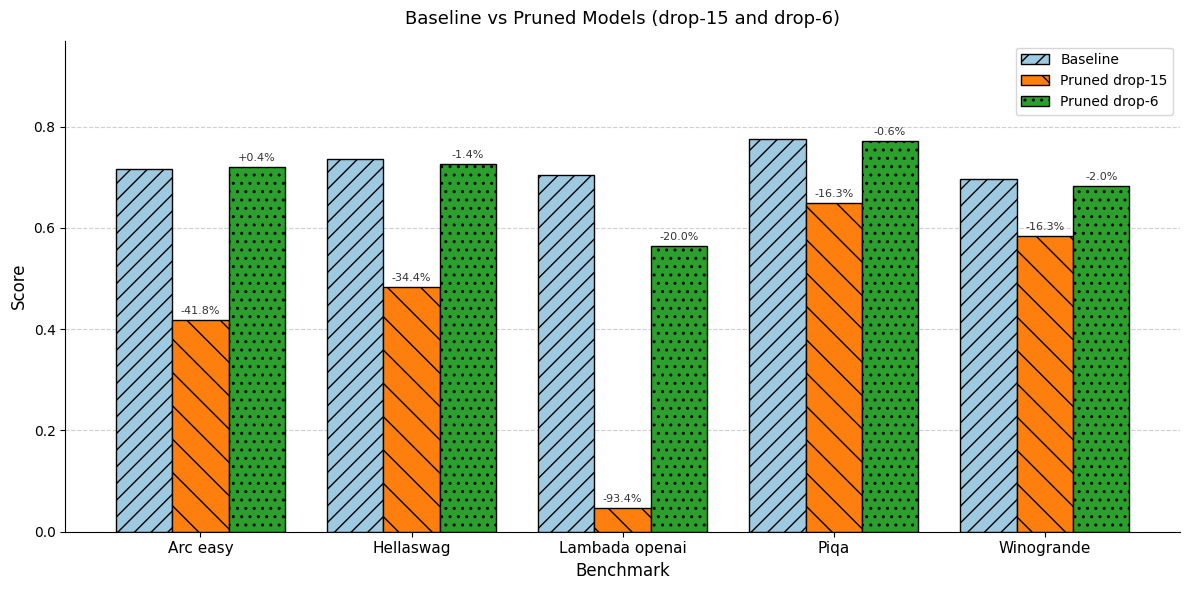

In [76]:
import matplotlib.pyplot as plt
import numpy as np

def get_score(d):
    return float(d.get("acc_norm", d.get("accuracy")))

if not RUN_FULL_BENCHMARKS:
    print("Enable RUN_FULL_BENCHMARKS=True to generate the comparison chart.")
else:
    available_experiments = sorted(experiment_results.keys(), reverse=True)  # [15, 6]
    common_keys = [
        k for k in base_benchmarks
        if all(k in experiment_results[n]["benchmarks"] for n in available_experiments)
    ]

    benchmarks = common_keys
    baseline_scores = [get_score(base_benchmarks[k]) for k in benchmarks]

    exp_scores = {
        n: [get_score(experiment_results[n]["benchmarks"][k]) for k in benchmarks]
        for n in available_experiments
    }

    x = np.arange(len(benchmarks))
    num_series = 1 + len(available_experiments)
    bar_width = 0.8 / num_series

    fig, ax = plt.subplots(figsize=(max(8, len(benchmarks) * 2.4), 6))

    # Baseline bars
    ax.bar(
        x - 0.4 + bar_width / 2, baseline_scores,
        width=bar_width,
        color="#9ecae1", edgecolor="black", linewidth=1.0, hatch="//",
        label="Baseline"
    )

    # Pruned variants
    colors = {15: "#ff7f0e", 6: "#2ca02c"}
    hatches = {15: "\\", 6: ".."}

    for i, n in enumerate(available_experiments, start=1):
        offsets = x - 0.4 + (i + 0.5) * bar_width
        bars = ax.bar(
            offsets, exp_scores[n],
            width=bar_width,
            color=colors.get(n, "#9467bd"),
            edgecolor="black",
            linewidth=1.0,
            hatch=hatches.get(n, "xx"),
            label=f"Pruned drop-{n}"
        )
        deltas = [
            ((p - b) / b * 100) if b != 0 else 0.0
            for b, p in zip(baseline_scores, exp_scores[n])
        ]
        for bar, delta in zip(bars, deltas):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.008,
                f"{delta:+.1f}%",
                ha="center",
                va="bottom",
                fontsize=8,
                color="#333333",
            )

    ax.set_xticks(x)
    ax.set_xticklabels([b.replace("_", " ").capitalize() for b in benchmarks], fontsize=11)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_xlabel("Benchmark", fontsize=12)
    ax.set_title("Baseline vs Pruned Models (drop-15 and drop-6)", fontsize=13, pad=12)
    ax.set_ylim(0, min(1.0, max(baseline_scores + sum(exp_scores.values(), [])) * 1.25))
    ax.yaxis.grid(True, linestyle="--", alpha=0.6)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=10)

    plt.tight_layout()
    plt.savefig("benchmark_results_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

In [81]:
memory_only_results = {}
for n in sorted(output_dirs):
    tmp_model = AutoModelForCausalLM.from_pretrained(
        output_dirs[n], torch_dtype=TORCH_DTYPE, device_map=device, trust_remote_code=True
    )
    memory_only_results[n] = measure_memory_allocation(
        tmp_model, tokenizer, PROMPT, max_new_tokens=MAX_NEW_TOKENS
    )
    del tmp_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

memory_only_results

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


{6: {'static_vram_mb': 10295.64,
  'dynamic_delta_mb': 78.72,
  'throughput_tokens_s': 24.81,
  'generated_text': ' What are the main challenges and challenges of AI? What are the main applications of AI? What are the main challenges and challenges of AI? What are the main applications of AI? What are the main challenges and challenges of AI? What are the main applications of AI? What are the main challenges and challenges of AI? What are the main applications of AI? What are the main challenges and challenges of AI? What are the main applications of AI? What are the main challenges and challenges of AI? What are the main applications of AI? What are the main challenges and challenges of AI? What are the main applications of AI? What are the main challenges and challenges of AI? What are the main applications of AI? What are the main challenges and challenges of AI? What are the main applications of AI? What are the main challenges and challenges of AI? What are the main applications o

In [78]:
for n in sorted(experiment_results):
    print(f"drop-{n}")
    print(experiment_results[n]["memory_results"])

drop-6
{'static_vram_mb': 11688.22, 'dynamic_delta_mb': 94.18, 'throughput_tokens_s': 24.42, 'generated_text': ' What are the main challenges and challenges of AI? What are the main applications of AI? What are the main challenges and challenges of AI? What are the main applications of AI? What are the main challenges and challenges of AI? What are the main applications of AI? What are the main challenges and challenges of AI? What are the main applications of AI? What are the main challenges and challenges of AI? What are the main applications of AI? What are the main challenges and challenges of AI? What are the main applications of AI? What are the main challenges and challenges of AI? What are the main applications of AI? What are the main challenges and challenges of AI? What are the main applications of AI? What are the main challenges and challenges of AI? What are the main applications of AI? What are the main challenges and challenges of AI? What are the main applications of A

In [79]:
import pandas as pd

rows = []
for n in sorted(experiment_results):
    mem = experiment_results[n]["memory_results"]
    rows.append({
        "experiment": f"drop-{n}",
        "static_vram_mb": mem["static_vram_mb"],
        "dynamic_delta_mb": mem["dynamic_delta_mb"],
        "throughput_tokens_s": mem["throughput_tokens_s"],
    })

pd.DataFrame(rows)

,experiment,static_vram_mb,dynamic_delta_mb,throughput_tokens_s
0,drop-6,11688.22,94.18,24.42
1,drop-15,10824.12,67.10,27.43


In [82]:
baseline_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=TORCH_DTYPE, device_map=device
)
baseline_memory = measure_memory_allocation(
    baseline_model, tokenizer, PROMPT, max_new_tokens=MAX_NEW_TOKENS
)
del baseline_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

baseline_memory

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


{'static_vram_mb': 10583.68,
 'dynamic_delta_mb': 109.57,
 'throughput_tokens_s': 21.93,
 'generated_text': ' Include a discussion of the major challenges and opportunities facing the field today.\nArtificial intelligence (AI) is a field of computer science that deals with the creation of intelligent machines that can perform tasks that typically require human intelligence, such as visual perception, speech recognition, decision-making, and language translation. The history of AI can be traced back to the 1950s, when the field was first established. In this essay, we will explore the history of AI, covering all major milestones from the 1950s to the present day. We will also discuss the major challenges and opportunities facing the field today.\nThe 1950s: The Birth of AI\nThe 1950s marked the birth of AI, with the first major milestone being the creation of the first AI program, called the Logic Theorist. Developed by Allen Newell and Herbert Simon at Carnegie Mellon University, Logic

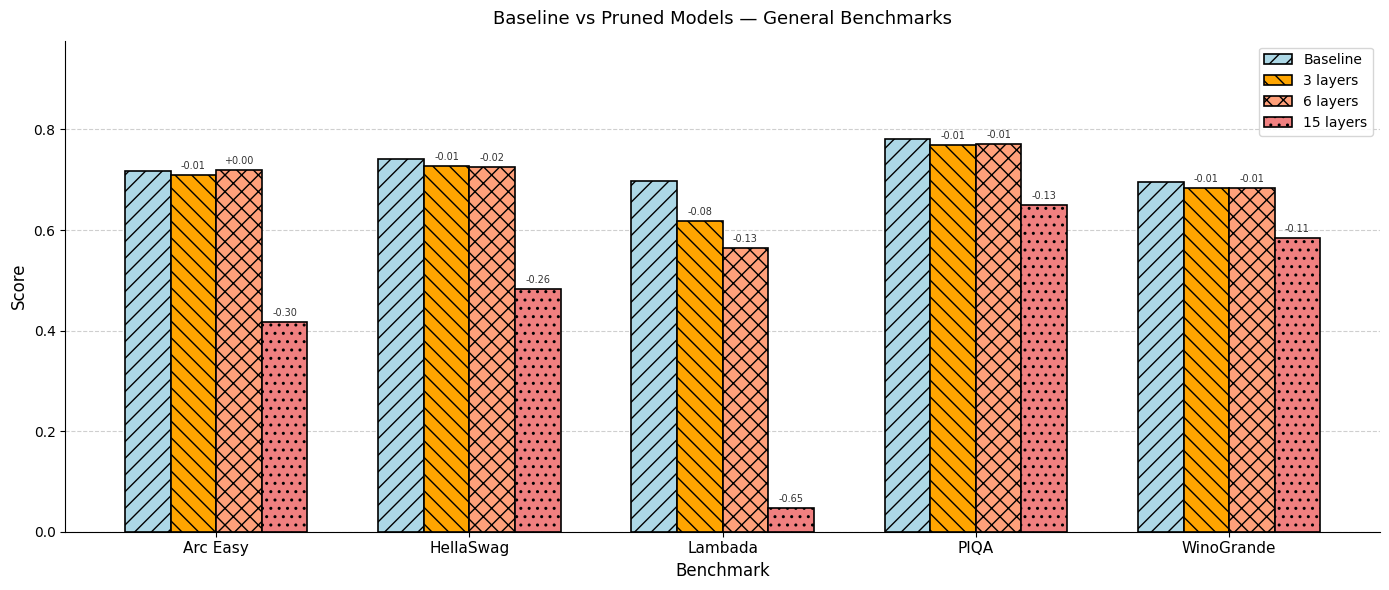

In [84]:
import matplotlib.pyplot as plt
import numpy as np

benchmarks = ["arc_easy", "hellaswag", "lambada", "piqa", "winogrande"]
labels = ["Arc Easy", "HellaSwag", "Lambada", "PIQA", "WinoGrande"]

scores = {
    "Baseline":  [0.7180, 0.7405, 0.6969, 0.7813, 0.6961],
    "3 layers":  [0.7104, 0.7274, 0.6189, 0.7693, 0.6843],
    "6 layers":  [0.7197, 0.7254, 0.5639, 0.7715, 0.6827],
    "15 layers": [0.4175, 0.4825, 0.0464, 0.6496, 0.5833],
}

deltas = {
    "3 layers":  [s - b for s, b in zip(scores["3 layers"],  scores["Baseline"])],
    "6 layers":  [s - b for s, b in zip(scores["6 layers"],  scores["Baseline"])],
    "15 layers": [s - b for s, b in zip(scores["15 layers"], scores["Baseline"])],
}

hatches   = ["//", "\\\\", "xx", ".."]
colors    = ["lightblue", "orange", "lightsalmon", "lightcoral"]
n_models  = len(scores)
n_benchmarks = len(benchmarks)
bar_width = 0.18
x = np.arange(n_benchmarks)

fig, ax = plt.subplots(figsize=(14, 6))

for i, (model_name, model_scores) in enumerate(scores.items()):
    offset = (i - n_models / 2 + 0.5) * bar_width
    bars = ax.bar(
        x + offset,
        model_scores,
        width=bar_width,
        color=colors[i],
        edgecolor="black",
        linewidth=1.2,
        hatch=hatches[i],
        label=model_name,
    )
    # Delta annotations only for pruned models
    if model_name != "Baseline":
        for bar, delta in zip(bars, deltas[model_name]):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.008,
                f"{delta:+.2f}",
                ha="center",
                va="bottom",
                fontsize=7,
                color="#333333",
            )

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("Score", fontsize=12)
ax.set_xlabel("Benchmark", fontsize=12)
ax.set_title(
    "Baseline vs Pruned Models — General Benchmarks",
    fontsize=13,
    pad=12,
)
ax.set_ylim(0, min(1.0, max(scores["Baseline"]) * 1.25))
ax.yaxis.grid(True, linestyle="--", alpha=0.6)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(fontsize=10, loc="upper right")

plt.tight_layout()
plt.savefig("benchmark_results_all.png", dpi=150, bbox_inches="tight")
plt.show()